<a href="https://colab.research.google.com/github/Rendhazuper/PCVK_Genap_2025/blob/main/Week6_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [14]:
from google.colab import drive
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from PIL import Image as im

In [6]:
def convolution2d (image, kernel, stride, padding):
    kernel = np.array(kernel)
    image = np.array(image)

    i_h, i_w = image.shape
    k_h, k_w = kernel.shape

    if padding > 0:
        image_padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    else:
        image_padded = image

    o_h = ((i_h + 2*padding - k_h) // stride) + 1
    o_w = ((i_w + 2*padding - k_w) // stride) + 1

    output = np.zeros((o_h, o_w))

    for y in range(o_h):
        for x in range(o_w):
            region = image_padded[
                y*stride : y*stride + k_h,
                x*stride : x*stride + k_w
            ]
            output[y, x] = np.sum(region * kernel)

    return output

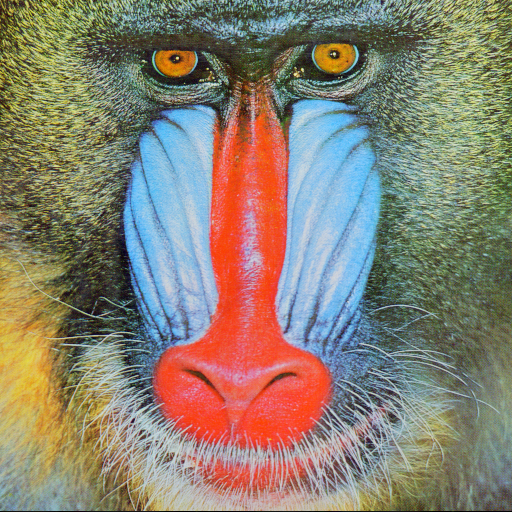

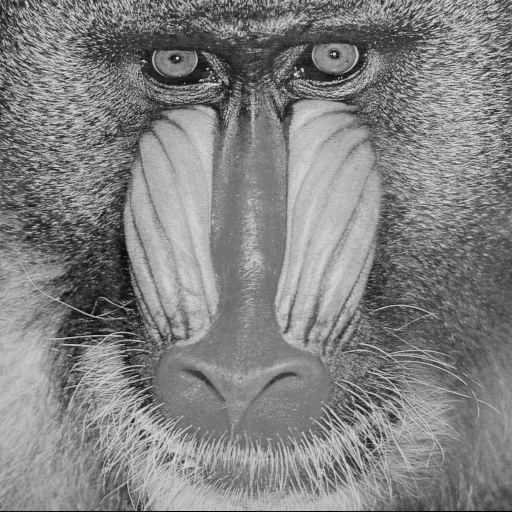

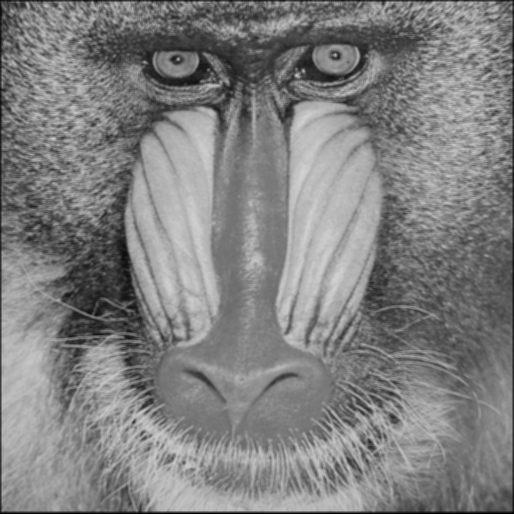

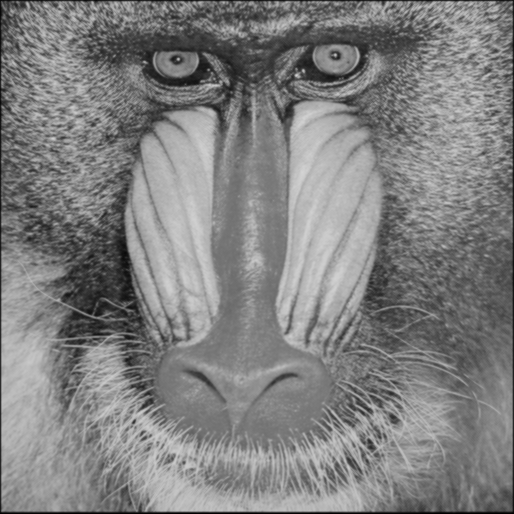

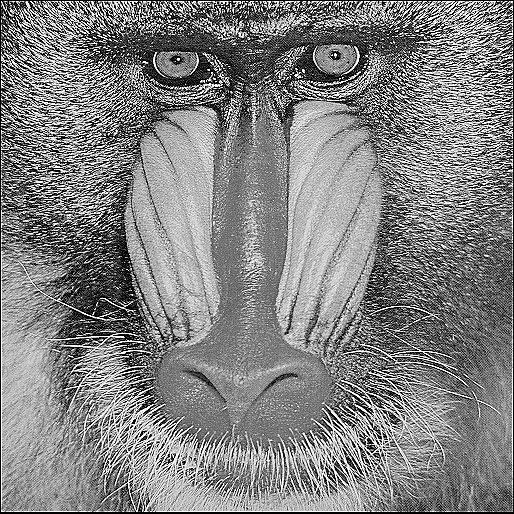

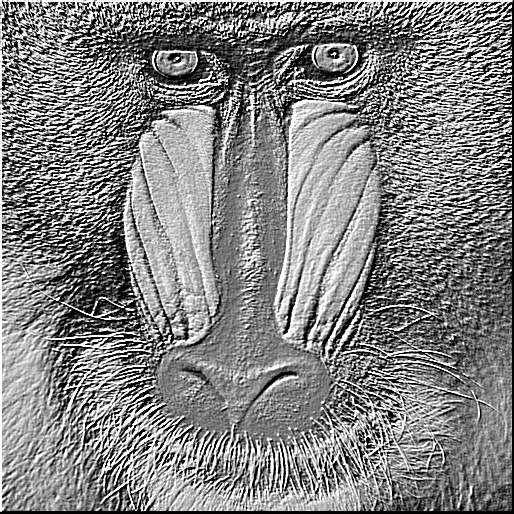

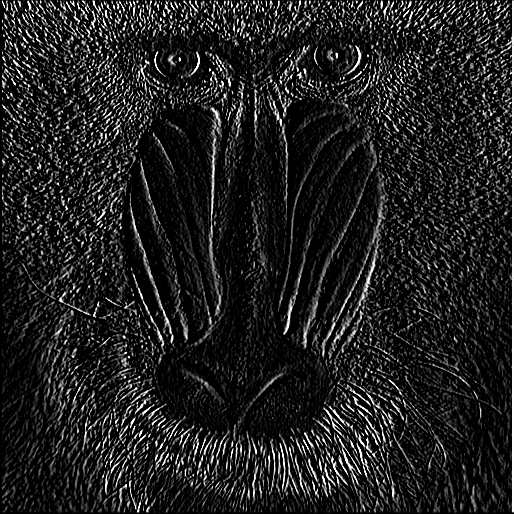

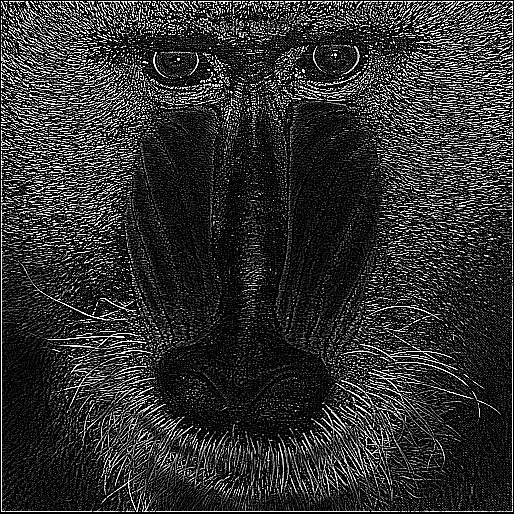

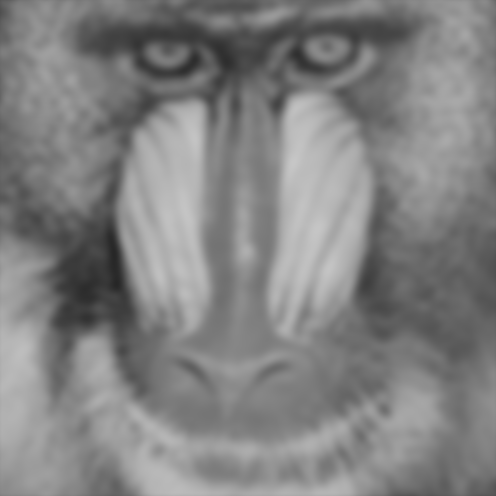

In [15]:
img = cv.imread('/content/drive/MyDrive/PCVK/mandrill.png')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


kernel_avg = (1/9)*(np.array([[1,1,1],
                           [1,1,1],
                           [1,1,1]]))

kernel_low = (1/12)*(np.array([[1,1,1],
                           [1,4,1],
                           [1,1,1]]))

kernel_high = np.array([[-1,0,1],
                        [-1,0,3],
                        [-3,0,1]])

kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])

kernel_emboss = np.array([[-2,-1,0],
                           [-1,1,1],
                           [0,1,2]])

kernel_left_sobel_edge = np.array([[1,0,-1],
                                   [2,0,-2],
                                   [1,0,-1]])

kernel_canny_edge = np.array([[-1,-1,-1],
                              [-1,8,-1],
                              [-1,-1,-1]])
kernel_size = 21
sigma=math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @gaussian_kernel.transpose()


avg = convolution2d(img_gray, kernel_avg, 1, 2)
low = convolution2d(img_gray, kernel_low, 1, 2)
sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)
embos = convolution2d(img_gray, kernel_emboss, 1, 2)
leftsobeledge = convolution2d(img_gray, kernel_left_sobel_edge, 1, 2)
cannyedge = convolution2d(img_gray, kernel_canny_edge, 1, 2)
blur = convolution2d(img_gray, gauss_kernel, 1, 2)

cv2_imshow(img)
cv2_imshow(img_gray)
cv2_imshow(avg)
cv2_imshow(low)
cv2_imshow(sharpen)
cv2_imshow(embos)
cv2_imshow(leftsobeledge)
cv2_imshow(cannyedge)
cv2_imshow(blur)

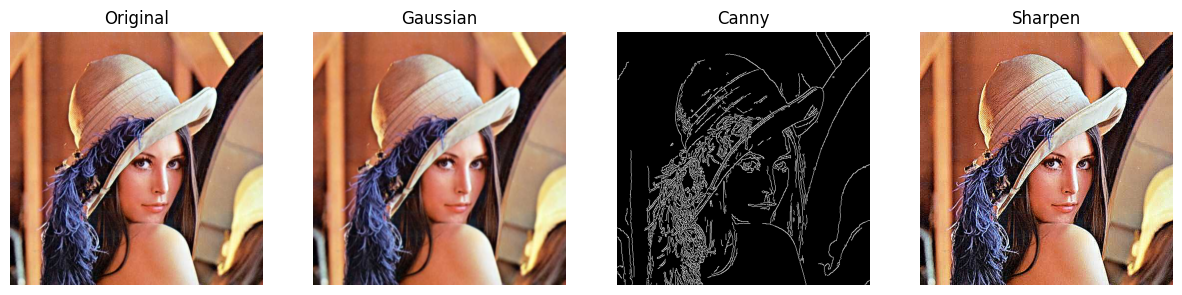

In [16]:
def show_side_by_side(imgs, tits, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, tit) in enumerate(zip(imgs, tits)):
    if len(img.shape) == 2:
      plt.subplot(1, len(imgs), i+1)
      plt.imshow(img, cmap='gray')
    else:
      plt.subplot(1, len(imgs), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(tit)
    plt.axis("off")
  plt.show()

img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(img_gray, 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpen = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, edges, sharpen], ["Original", "Gaussian", "Canny", "Sharpen"])

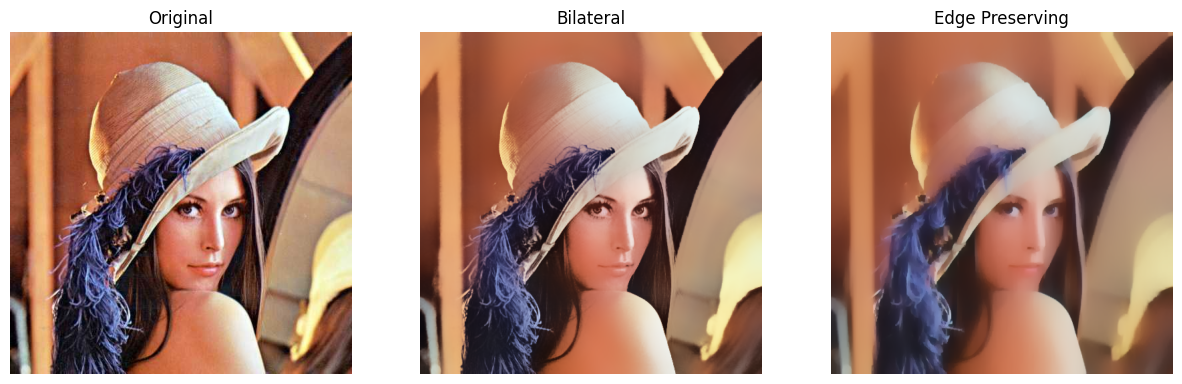

In [17]:
bilateral = cv.bilateralFilter(img, 50, 100, 100)

edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve], ["Original", "Bilateral", "Edge Preserving"])



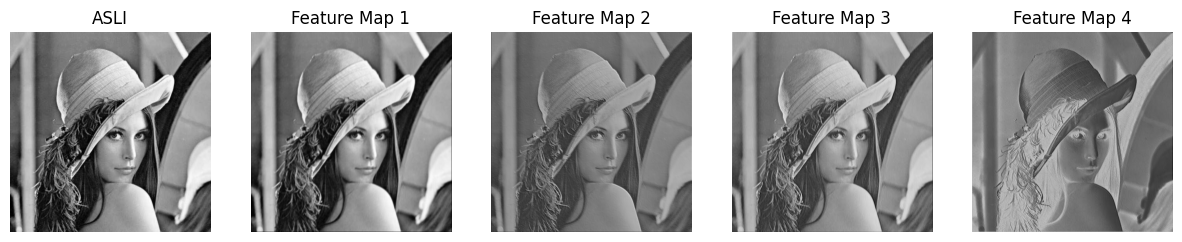

In [18]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, stride=1, padding=1)

  def forward(self, x):
    x = self.conv1(x)
    return x

model = SimpleCNN()


img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0)/255.0

with torch.no_grad():
  features = model(img_tensor)


feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["ASLI"] + [f"Feature Map {i+1}" for i in range(len(feature_maps))])


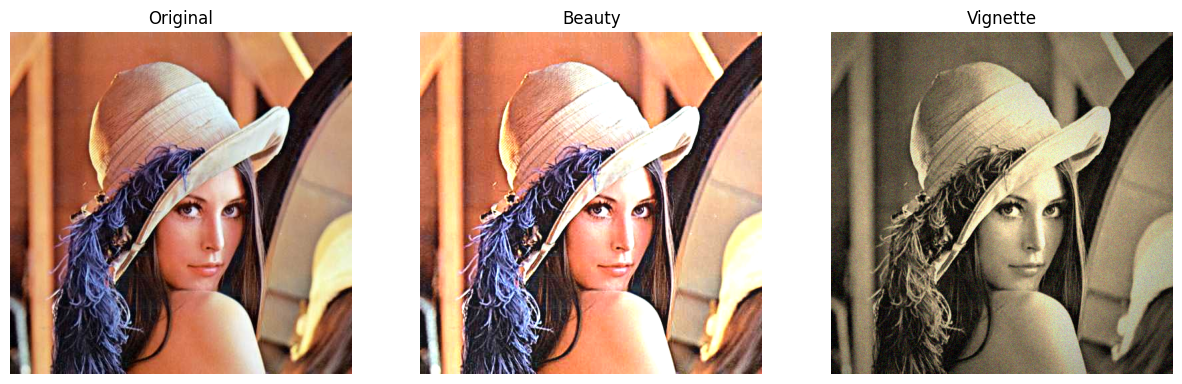

In [19]:
smooth = cv.bilateralFilter(img, 15, 75, 75)

gaussian = cv.GaussianBlur(img, (0,0), 3)
sharpened = cv.addWeighted(img, 1.5, gaussian, -0.5, 0)

alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

sepia_kernel = np.array([[0.272, 0.534, 0.131],
                  [0.349, 0.686, 0.168],
                  [0.393, 0.769, 0.189]])
sepia = (cv.transform(img, sepia_kernel))
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows,cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(cols, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
  vignette[:,:,i] = vignette[:,:,i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Original","Beauty", "Vignette"])

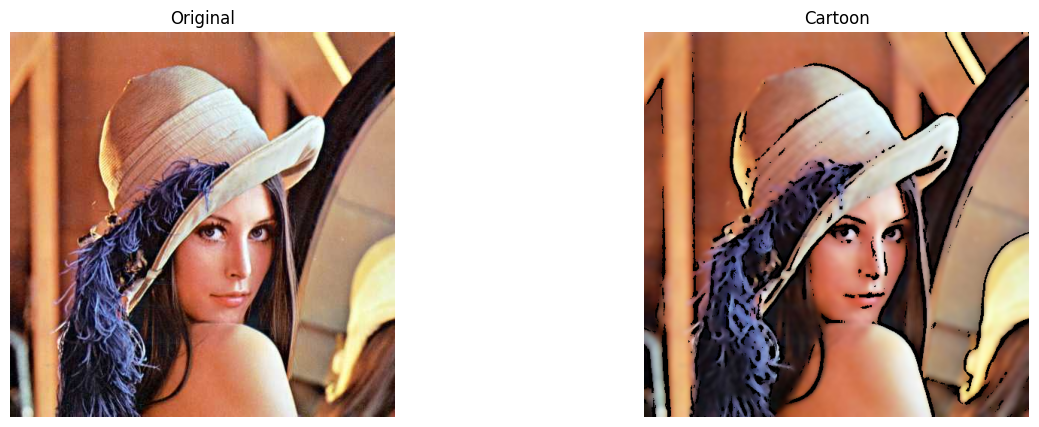

In [20]:
gray_blur = cv.medianBlur(img_gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9,9)

color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ["Original", "Cartoon"])

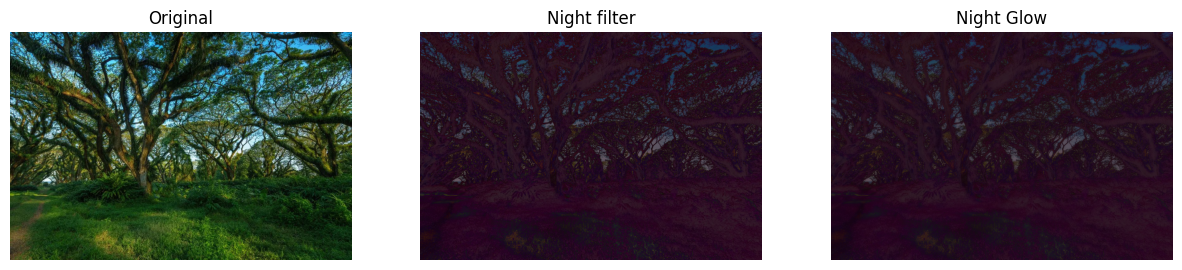

In [21]:
img = cv.imread('/content/drive/MyDrive/PCVK/djawatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

kernel = np.ones((15,15), np.float32) / 255.0
glow = cv.filter2D(night, -1, kernel)

night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow], ["Original","Night filter", "Night Glow"])

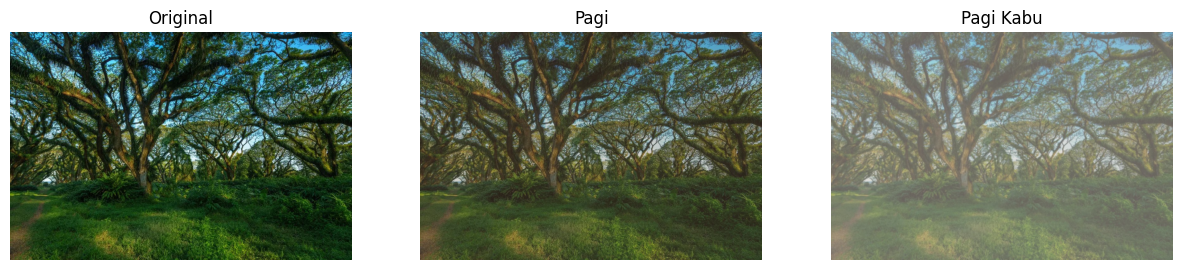

In [23]:
a = 0.9
b = 20
soft = cv.convertScaleAbs(img, alpha=a, beta=b)

warm_tint = np.full_like(soft, (40,70,120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

kernel = cv.getGaussianKernel(3,3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 00)

show_side_by_side([img, pagi, kabut], ["Original", "Pagi", "Pagi Kabu"])